In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Load training data
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

In [22]:
# Step 1: Remove rows where target is missing or invalid
df = df[df['Loan_Status'].isin(['Y', 'N'])]  # Keep only valid labels
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})  # Encode target

In [23]:
# Step 2: Impute missing values
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

imputer_cat = SimpleImputer(strategy='most_frequent')
imputer_num = SimpleImputer(strategy='median')

df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])
df[num_cols] = imputer_num.fit_transform(df[num_cols])

In [24]:
# Step 3: Feature Engineering
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['DTI'] = df['LoanAmount'] / (df['TotalIncome'] + 1)  # Avoid divide by 0
df['IncomeStability'] = df['Education'].apply(lambda x: 1 if x == 'Graduate' else 0) + \
                        df['Self_Employed'].apply(lambda x: 1 if x == 'No' else 0)

In [25]:
# Step 4: Encode categorical features
le = LabelEncoder()
for col in cat_cols:
    if col != 'Loan_ID':
        df[col] = le.fit_transform(df[col])

In [26]:
# Step 5: Drop unnecessary columns
df.drop(['Loan_ID'], axis=1, inplace=True)

In [27]:
# Step 6: Define X and y
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [28]:
# Step 7: Train/test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Optional: Sanity check for NaNs
print("Missing in y_train:", y_train.isnull().sum())
print("Missing in y_val:", y_val.isnull().sum())

# If still any NaNs (just in case), drop them
train_mask = y_train.notnull()
X_train = X_train[train_mask]
y_train = y_train[train_mask]

val_mask = y_val.notnull()
X_val = X_val[val_mask]
y_val = y_val[val_mask]

Missing in y_train: 0
Missing in y_val: 0


In [30]:
# Step 8: Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [31]:
# Step 9: Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [32]:
# Step 10: Evaluate model
y_pred = model.predict(X_val)
print("\nAccuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))


Accuracy: 0.8048780487804879

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.51      0.65        43
         1.0       0.79      0.96      0.87        80

    accuracy                           0.80       123
   macro avg       0.83      0.74      0.76       123
weighted avg       0.82      0.80      0.79       123


Confusion Matrix:
 [[22 21]
 [ 3 77]]


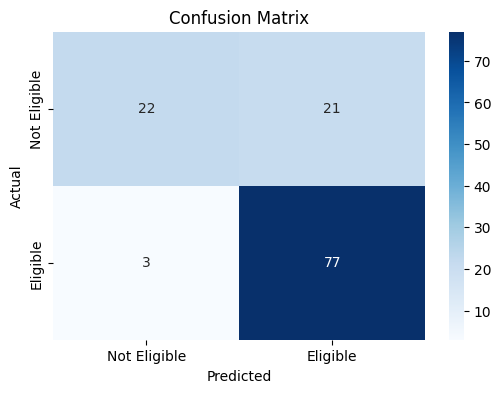

In [33]:
# Step 11: Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=["Not Eligible", "Eligible"], yticklabels=["Not Eligible", "Eligible"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [34]:
# Evaluation
print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))

Accuracy: 0.8048780487804879

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.51      0.65        43
         1.0       0.79      0.96      0.87        80

    accuracy                           0.80       123
   macro avg       0.83      0.74      0.76       123
weighted avg       0.82      0.80      0.79       123


Confusion Matrix:
 [[22 21]
 [ 3 77]]


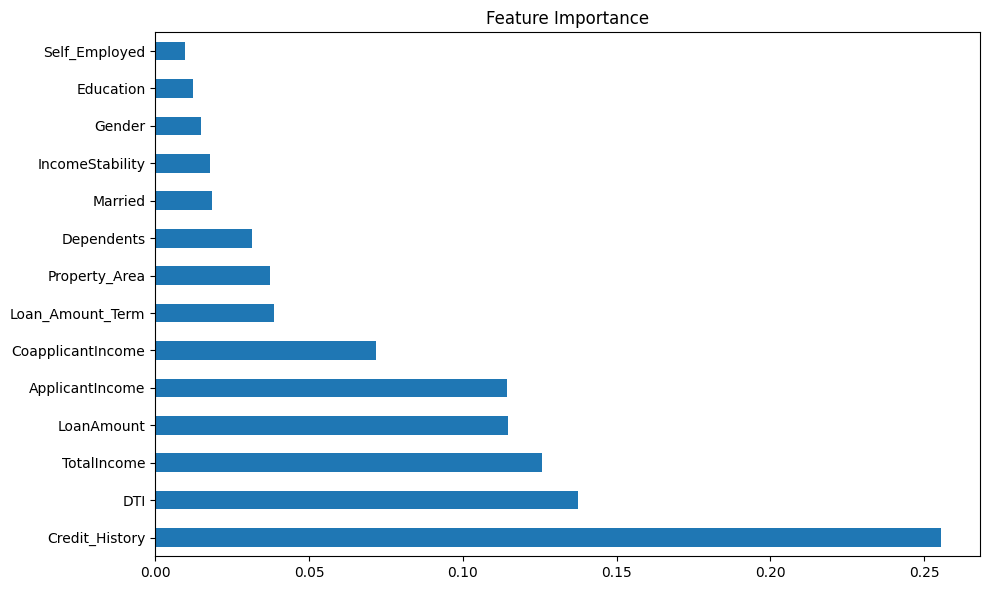

In [35]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='barh', figsize=(10,6), title="Feature Importance")
plt.tight_layout()
plt.show()

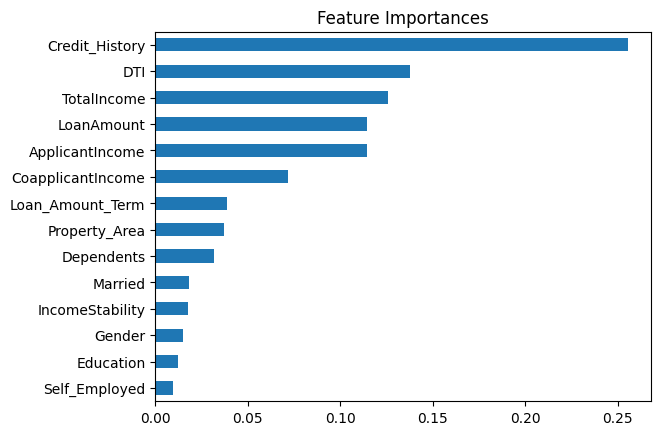

In [36]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title("Feature Importances")
plt.show()

In [38]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve

In [39]:
# Cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
print("Mean CV ROC-AUC:", np.mean(cv_scores))

Mean CV ROC-AUC: 0.8072526971808214


In [40]:
# Predict probabilities
y_probs = model.predict_proba(X_val)[:, 1]

In [41]:
# ROC-AUC on validation set
auc = roc_auc_score(y_val, y_probs)
print("Validation ROC-AUC:", auc)

Validation ROC-AUC: 0.7755813953488372


In [42]:
val_results = pd.DataFrame({
    'Actual': y_val,
    'Predicted': y_pred,
    'Probability': y_probs
})
val_results.to_csv("validation_predictions.csv", index=False)

In [43]:
import joblib
joblib.dump(model, 'loan_eligibility_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']